# Dispatchable solar cost, getuned op PyPSA-Earth Run A / Run B

Vervolg op de eerdere Ember-reproductie: in plaats van externe aannames
($125/kWh capex, $50/MWh solar-LCOE, 50% opslagaandeel) worden hier alle
inputs rechtstreeks uit je eigen gesolvde PyPSA-Earth netwerken gehaald.

| Grootheid | Extern (vorige versie) | Nu: bron in je eigen netwerk |
|---|---|---|
| Solar LCOE | IEA Scaling Solar, $50/MWh (2016) | `n.statistics.capex/opex/supply` op **Run A** (zonder BESS) |
| BESS energie-/vermogenskosten | Ember $125/kWh | `capital_cost` direct van de Store ("store") en Link ("bicharger") in **Run B** |
| Efficiëntie | 90% aangenomen | `n.links.efficiency` van de bicharger-link |
| Levensduur | 20 jaar aangenomen | `n.stores.lifetime`, met terugval naar 16 jaar (je eigen cost-tabel) als dat niet gezet is |
| Utilisatiegraad | 80% aangenomen (Ember) | berekend uit werkelijke dispatch: cycli/dag die het model kiest |
| Opslagaandeel | 50% aangenomen (Ember) | berekend uit werkelijke dispatch: jaarlijkse ontlading / jaarlijkse zonopwek |

Degradatie (2%/jaar) blijft een externe aanname -- PyPSA modelleert dat niet
inherent tenzij je het zelf als constraint hebt toegevoegd.

Alles hieronder is eerst getest tegen synthetische Run A/B-netwerken (zelfde
opzet als je eigen model: Store + Link voor de "store"/"bicharger"-splitsing)
voordat het is opgeleverd.

## 1. Basisfuncties (Ember-gevalideerde LCOS-reproductie, ongewijzigd)

In [1]:
"""
LCOS + dispatchable-solar cost calculator, reproducing Ember Energy's
"How cheap is battery storage?" (Dec 2025, data as of Oct 2025) methodology.

Validated against Ember's own published checkpoints before delivery:
  - capex $125/kWh -> LCOS ~$65/MWh (their central case)
  - capex $125/kWh, Lazard-aligned inputs (r=11%, eff=92%, util=96%) -> LCOS ~$65/MWh
  - lifetime 10->20yr, efficiency 85->90%, discount 10->7% bridges $100/MWh -> $65/MWh
  - LCOS $65/MWh, storage_share=50%, solar LCOE $43/MWh -> +$33/MWh, total $76/MWh
"""


def capital_recovery_factor(discount_rate, lifetime_years):
    r, n = discount_rate, lifetime_years
    return r * (1 + r) ** n / ((1 + r) ** n - 1)


def lcos(capex_per_kwh, discount_rate=0.07, lifetime_years=20,
         efficiency_rt=0.90, utilization=0.80, degradation_rate=0.02,
         opex_pct=0.02):
    """
    Levelised Cost of Storage, $/MWh discharged (Ember's definition: cost of
    SHIFTING one MWh in time; charging electricity cost excluded).

    Key structural point (not obvious from Ember's report text, found by
    calibrating against their own published checkpoints): round-trip
    efficiency does not enter as a cost -- it reduces discharged energy
    per rated kWh, because only a fraction of what is cycled through the
    battery survives the round trip as billable AC output.

    capex_per_kwh   : $/kWh installed energy capacity (overnight capital cost)
    discount_rate   : e.g. 0.07
    lifetime_years  : e.g. 20
    efficiency_rt   : round-trip AC-AC efficiency, e.g. 0.90
    utilization     : fraction of one full discharge cycle achieved per day
    degradation_rate: annual capacity fade, e.g. 0.02
    opex_pct        : annual fixed O&M as fraction of capex, e.g. 0.02
    """
    crf = capital_recovery_factor(discount_rate, lifetime_years)
    annual_cost = capex_per_kwh * crf + opex_pct * capex_per_kwh  # $/kWh/yr

    avg_degradation = sum((1 - degradation_rate) ** t
                           for t in range(lifetime_years)) / lifetime_years
    annual_energy = 365 * utilization * efficiency_rt * avg_degradation  # kWh discharged/yr per kWh installed

    return annual_cost / annual_energy * 1000  # $/MWh


def dispatchable_solar_cost(solar_lcoe, lcos_value, storage_share=0.5):
    """
    Cost of turning daytime-only solar into dispatchable solar by storing
    and time-shifting a fraction of daily generation (Ember Section 3).

    solar_lcoe    : $/MWh, LCOE of the underlying solar generation
    lcos_value    : $/MWh, levelised cost of storage
    storage_share : fraction of daily solar generation that is stored
    """
    added_cost = storage_share * lcos_value
    total_cost = solar_lcoe + added_cost
    return {"added_cost_per_MWh": added_cost,
            "dispatchable_solar_cost_per_MWh": total_cost}




## 2. Extractiefuncties voor PyPSA-netwerken

In [2]:
"""
Extraction + LCOS pipeline that reads directly from solved PyPSA-Earth
Run A (no BESS) / Run B (BESS endogenous) networks, replacing the
externally-assumed inputs (Ember's $125/kWh, IEA's $50/MWh, 50% storage
share) with values read from your own model.
"""
import numpy as np


def extract_solar_lcoe(n, generator_carrier="solar"):
    """(capex + opex) / supply for a carrier, using n.statistics so
    snapshot weighting (representative periods) is handled correctly."""
    capex = n.statistics.capex(groupby="carrier").get(("Generator", generator_carrier), 0.0)
    opex = n.statistics.opex(groupby="carrier").get(("Generator", generator_carrier), 0.0)
    supply = n.statistics.supply(groupby="carrier").get(("Generator", generator_carrier), 0.0)
    if supply == 0:
        raise ValueError(f"No supply found for carrier '{generator_carrier}' -- check the carrier name")
    return (capex + opex) / supply  # currency/MWh


def extract_bess_annualized_costs(n, store_name, charger_link_name):
    """
    Reads capital_cost DIRECTLY off the Store/Link components. In PyPSA
    (and PyPSA-Earth's technology-data convention) this is already the
    fully annualized cost -- annuity(discount_rate, lifetime) x overnight
    investment, PLUS fixed O&M, combined into one number. Do not add a
    separate opex_pct on top of this, or FOM gets double-counted.
    Verify this convention holds in your own cost.csv / config before trusting it blindly.
    """
    annual_energy_cost_per_mwh = n.stores.at[store_name, "capital_cost"]
    annual_power_cost_per_mw = n.links.at[charger_link_name, "capital_cost"]
    energy_cap = n.stores.at[store_name, "e_nom_opt"]
    power_cap = n.links.at[charger_link_name, "p_nom_opt"]
    duration_hours = energy_cap / power_cap if power_cap > 0 else float("nan")
    return {
        "annual_energy_cost_per_mwh": annual_energy_cost_per_mwh,
        "annual_power_cost_per_mw": annual_power_cost_per_mw,
        "energy_capacity_mwh": energy_cap,
        "power_capacity_mw": power_cap,
        "duration_hours": duration_hours,
    }


def extract_efficiency(n, charger_link_name):
    return n.links.at[charger_link_name, "efficiency"]


def extract_lifetime(n, store_name, fallback_years=16):
    """PyPSA component lifetime defaults to inf unless explicitly set in
    the network build; falls back to a manual value (flag if this triggers,
    it means lifetime isn't actually coming from your model)."""
    lt = n.stores.at[store_name, "lifetime"]
    if not np.isfinite(lt):
        print(f"  [!] Store '{store_name}' has no finite lifetime set in the network "
              f"-- using fallback of {fallback_years} years. Check your cost.csv / build script.")
        return fallback_years
    return lt


def extract_utilization(n, store_name, discharge_link_name):
    """
    Equivalent full cycles per day actually achieved by the optimiser,
    as a fraction of one cycle/day -- computed from the model's own
    dispatch rather than assumed externally (Ember uses a flat 80%
    assumption; your model reveals what Senegal's own demand/solar
    profile actually implies).
    """
    w = n.snapshot_weightings.generators
    annual_discharge = (-n.links_t.p1[discharge_link_name] * w).sum()  # MWh delivered to AC bus/yr
    energy_cap = n.stores.at[store_name, "e_nom_opt"]
    if energy_cap == 0:
        return 0.0
    equivalent_cycles_per_year = annual_discharge / energy_cap
    return equivalent_cycles_per_year / 365


def extract_storage_share(n, discharge_link_name, solar_carrier="solar"):
    """Annual battery discharge (delivered to AC bus) as a fraction of
    annual solar generation -- the model-derived analogue of Ember's
    externally-assumed 50%."""
    w = n.snapshot_weightings.generators
    discharge = (-n.links_t.p1[discharge_link_name] * w).sum()
    solar_supply = n.statistics.supply(groupby="carrier").get(("Generator", solar_carrier), 0.0)
    return discharge / solar_supply


def lcos_from_annualized_costs(annual_energy_cost_per_mwh, annual_power_cost_per_mw,
                                duration_hours, efficiency_rt, utilization,
                                degradation_rate, lifetime_years):
    """
    LCOS ($/MWh discharged) built from ALREADY-annualized capital costs
    (as stored directly in a solved PyPSA network), instead of raw
    overnight capex + a separately assumed discount rate. See
    core.lcos() for the from-scratch, Ember-validated version.
    """
    annual_energy_cost_per_kwh = annual_energy_cost_per_mwh / 1000
    annual_power_cost_per_kwh = (annual_power_cost_per_mw / 1000) / duration_hours
    annual_cost_per_kwh = annual_energy_cost_per_kwh + annual_power_cost_per_kwh

    avg_degradation = sum((1 - degradation_rate) ** t
                           for t in range(int(round(lifetime_years)))) / lifetime_years
    annual_energy = 365 * utilization * efficiency_rt * avg_degradation
    return annual_cost_per_kwh / annual_energy * 1000


## 3. Synthetisch Run A / Run B netwerk (voor test en demonstratie)

Zelfde structuur als je eigen model: BESS als een Store-component
("store", energie, EUR/MWh/jaar) plus een Link-component ("bicharger",
vermogen, EUR/MW/jaar), op een aparte DC-bus. `p_nom_min`/`e_nom_min`
forceren hier een kleine batterij zodat de demo iets heeft om te
extraheren -- verwijder die floors zodra je dit op je eigen Run B-netwerk
richt, want daar wil je juist de eigen keuze van de optimalisatie zien.

In [3]:
"""
Synthetic Senegal-style network with BESS split into Store (energy/"store")
+ Link (power/"bicharger"), matching the cost-table structure from the
earlier cost-benchmarking conversation (Lithium-Ion-LFP store + bicharger).
"""
import pypsa
import numpy as np
import pandas as pd


def build_network(include_bess: bool, seed: int = 0) -> pypsa.Network:
    rng = np.random.default_rng(seed)
    n = pypsa.Network()
    hours = pd.date_range("2030-01-01", periods=24 * 14, freq="h")
    n.set_snapshots(hours)
    # representative-period-style weighting, same idea as tsam typical days:
    # weight each snapshot so the 14 modelled days stand in for a full year
    n.snapshot_weightings[:] = 365 * 24 / len(hours)

    n.add("Bus", "senegal")
    n.add("Bus", "senegal_dc")  # DC side bus for the BESS, common PyPSA-Earth pattern

    t = np.arange(len(hours))
    hour_of_day = hours.hour.values
    base = 800 + 150 * np.sin(2 * np.pi * (hour_of_day - 6) / 24)
    evening_peak = 250 * np.exp(-0.5 * ((hour_of_day - 20) / 2.5) ** 2)
    demand = np.clip(base + evening_peak + rng.normal(0, 15, len(hours)), 400, None)
    n.add("Load", "load", bus="senegal", p_set=demand)

    n.add("Generator", "OCGT_existing", bus="senegal", carrier="OCGT",
          p_nom=450, p_nom_extendable=False, marginal_cost=180)
    n.add("Generator", "OCGT_new", bus="senegal", carrier="OCGT",
          p_nom=0, p_nom_extendable=True, capital_cost=60000, marginal_cost=180)

    solar_cf = np.clip(np.sin(np.pi * (hour_of_day - 6) / 12), 0, 1)
    solar_cf = np.where((hour_of_day >= 6) & (hour_of_day <= 18), solar_cf, 0)
    n.add("Generator", "Solar_new", bus="senegal", carrier="solar",
          p_nom=0, p_nom_extendable=True, p_max_pu=solar_cf,
          capital_cost=45000,   # EUR/MW/year, annualized (this is what PyPSA-Earth stores)
          marginal_cost=0.5)

    n.add("Generator", "load_shedding", bus="senegal", carrier="load_shedding",
          p_nom=1e5, marginal_cost=5000)

    if include_bess:
        # "store" component: energy capacity, EUR/MWh/year annualized capital cost
        # p_nom_min/e_nom_min force some deployment so this demo network
        # has non-zero BESS dispatch to extract storage_share from --
        # remove these floors when pointing at your real Run B network,
        # since there the optimiser's own decision is what you want to read.
        n.add("Store", "BESS_store", bus="senegal_dc", carrier="battery",
              e_nom=0, e_nom_min=80, e_nom_extendable=True,
              capital_cost=25139,     # EUR/MWh/year -- matches earlier "store" annualized figure
              e_cyclic=True)
        # "bicharger" component: power capacity, combined charger+discharger link
        n.add("Link", "BESS_bicharger", bus0="senegal", bus1="senegal_dc",
              p_nom=0, p_nom_min=25, p_nom_extendable=True,
              capital_cost=10362,     # EUR/MW/year -- matches earlier "bicharger" annualized figure
              efficiency=0.9193, marginal_cost=1)
        n.add("Link", "BESS_bicharger_rev", bus0="senegal_dc", bus1="senegal",
              p_nom=0, p_nom_extendable=True,
              capital_cost=0,          # cost already counted on the forward link
              efficiency=0.9193, marginal_cost=1)

    return n




## 4. Netwerken oplossen

In [4]:
import logging
logging.getLogger("pypsa").setLevel(logging.ERROR)
logging.getLogger("linopy").setLevel(logging.ERROR)

n_a = build_network(include_bess=False, seed=1)
n_a.optimize(solver_name="highs", solver_options={"output_flag": False})

n_b = build_network(include_bess=True, seed=1)
n_b.optimize(solver_name="highs", solver_options={"output_flag": False})

print("Run A objective:", round(n_a.objective, 1))
print("Run B objective:", round(n_b.objective, 1))

Run A objective: 859513923.1
Run B objective: 861432457.8


## 5. Alle inputs uit de netwerken extraheren

Let op de waarschuwing bij `extract_lifetime`: die triggert hier omdat de
synthetische Store geen `lifetime` heeft gezet (PyPSA default is `inf`).
Als dat ook in jouw echte netwerk gebeurt, komt de levensduur dus niet
echt uit je model -- controleer je cost.csv/build-script.

In [5]:
solar_lcoe = extract_solar_lcoe(n_a, generator_carrier="solar")
print(f"Solar LCOE (Run A, geen BESS): {solar_lcoe:.2f} EUR/MWh")

bess = extract_bess_annualized_costs(n_b, store_name="BESS_store", charger_link_name="BESS_bicharger")
print("BESS (Run B):", bess)

efficiency = extract_efficiency(n_b, "BESS_bicharger")
lifetime = extract_lifetime(n_b, "BESS_store")
utilization = extract_utilization(n_b, "BESS_store", "BESS_bicharger_rev")
storage_share = extract_storage_share(n_b, "BESS_bicharger_rev", solar_carrier="solar")

print(f"efficiency={efficiency:.4f}")
print(f"lifetime={lifetime}")
print(f"utilization (cycli/dag als fractie van 1): {utilization:.4f}")
print(f"storage_share (ontlading / zonopwek): {storage_share:.4f}")

Solar LCOE (Run A, geen BESS): 25.48 EUR/MWh
BESS (Run B): {'annual_energy_cost_per_mwh': 25139.0, 'annual_power_cost_per_mw': 10362.0, 'energy_capacity_mwh': 80.0, 'power_capacity_mw': 25.0, 'duration_hours': 3.2}
  [!] Store 'BESS_store' has no finite lifetime set in the network -- using fallback of 16 years. Check your cost.csv / build script.
efficiency=0.9193
lifetime=16
utilization (cycli/dag als fractie van 1): 0.0353
storage_share (ontlading / zonopwek): 0.0003


## 6. LCOS en dispatchable solar cost, volledig uit je eigen model

De `max(..., 0.01)`-guards zijn alleen nodig voor deze speelgoed-demo,
waar de geforceerde minimumbatterij nauwelijks wordt gebruikt (utilisatie
~3,5%, opslagaandeel ~0,03%) en dus een absurd hoge LCOS oplevert -- dat is
inhoudelijk correct gedrag (weinig doorvoer over een dure batterij = hoge
kosten per geleverde MWh), niet een bug. Op je echte Run B-netwerk, waar
de batterij endogeen op een zinnige schaal wordt gedimensioneerd, zou dit
een realistischer getal moeten geven; als het dat niet doet, is dat zelf
een relevante bevinding over hoe intensief je model de batterij inzet.

In [6]:
lcos_value = lcos_from_annualized_costs(
    annual_energy_cost_per_mwh=bess["annual_energy_cost_per_mwh"],
    annual_power_cost_per_mw=bess["annual_power_cost_per_mw"],
    duration_hours=bess["duration_hours"],
    efficiency_rt=efficiency,
    utilization=max(utilization, 0.01),
    degradation_rate=0.02,           # blijft een externe aanname, zie sectie 1
    lifetime_years=lifetime,
)
print(f"LCOS (volledig uit PyPSA): {lcos_value:.1f} EUR/MWh")

result = dispatchable_solar_cost(
    solar_lcoe=solar_lcoe,
    lcos_value=lcos_value,
    storage_share=max(storage_share, 0.01),
)
print(f"Extra kosten door opslag: {result['added_cost_per_MWh']:.1f} EUR/MWh")
print(f"Dispatchable solar cost:  {result['dispatchable_solar_cost_per_MWh']:.1f} EUR/MWh")

LCOS (volledig uit PyPSA): 2778.7 EUR/MWh
Extra kosten door opslag: 27.8 EUR/MWh
Dispatchable solar cost:  53.3 EUR/MWh


## 7. Dit op je echte Run A/B netwerken richten

```python
import pypsa
n_a = pypsa.Network("/Users/william/thesis/pypsa-earth/results/run_a_no_bess.nc")
n_b = pypsa.Network("/Users/william/thesis/pypsa-earth/results/run_b_with_bess.nc")
```

Dingen om te controleren/aan te passen voordat je vertrouwt op de output:

- **Componentnamen**: `generator_carrier="solar"`, `store_name="BESS_store"`,
  `charger_link_name="BESS_bicharger"` zijn placeholders. Check je eigen
  namen met `n_b.stores.index`, `n_b.links.index`,
  `n_a.generators.carrier.unique()`.
- **Meerdere nodes**: als je model meerdere Senegalese knooppunten heeft
  (in plaats van de single-bus toy hierboven), geeft `groupby="carrier"`
  in `extract_solar_lcoe` het systeembrede gemiddelde. Voor een
  node-specifieke LCOE (bv. alleen daar waar de BESS zit) moet je
  filteren op bus voordat je `n.statistics` aanroept, of de onderliggende
  `n.generators_t.p`/`n.generators.capital_cost` zelf aggregeren.
- **`capital_cost`-conventie checken**: de aanname hier is dat
  `capital_cost` op je Store/Link al volledig geannualiseerd is
  (investeringsannuïteit + FOM samen, de standaard PyPSA/technology-data
  conventie). Als jouw cost.csv FOM apart in `marginal_cost` of ergens
  anders verwerkt, moet je dat optellen bij `annual_energy_cost_per_mwh`
  /`annual_power_cost_per_mw` voordat je verder rekent, anders mis je een
  deel van de kosten.
- **Discharge-link naam voor storage_share/utilization**: hier
  `"BESS_bicharger_rev"` (de retourlink van DC- naar AC-bus). Als je BESS
  met een enkele symmetrische Link is gemodelleerd in plaats van twee
  losse links, moet je de tekenconventie in `n.links_t.p0`/`p1` narekenen
  om charge/discharge goed te scheiden.
- **Degradatie**: blijft een externe aanname (2%/jaar hier). Als je
  hiervoor wel een eigen aanname of bron hebt (bijvoorbeeld uit dezelfde
  Viswanathan/BNEF-vergelijking als eerder), zet die dan in plaats van de
  placeholder.
- **Meerdere jaren/periods**: als Run B een multi-period netwerk is
  (meerdere planningsjaren), geven `e_nom_opt`/`p_nom_opt` de capaciteit
  in het laatst gesolvde jaar; voor een LCOS per periode moet je per
  `investment_period` filteren voordat je extraheert.

## 8. Op de echte PyPSA-Earth resultaten (`baseline_bess_2030_overnight` / `baseline_no_bess_2030_overnight`)

Run A = `pypsa-earth/results/baseline_no_bess_2030_overnight/networks/elec_s_24_ec_lv1.0_1h.nc`,
Run B = `pypsa-earth/results/baseline_bess_2030_overnight/networks/elec_s_24_ec_lv1.0_1h.nc`.
Beide zijn al gesolved (echte dispatch aanwezig, 8760 snapshots, niet-triviale
objective). Dit is de **electricity-only** pipeline (`prepare_network.py` /
`solve_network`, geen sector-koppeling), single-year 2030 -- er is geen
jaar-wildcard in deze bestandsnaam zoals bij de vorige `no_bess`/`bess`-runfamilie,
dus geen `YEAR`-variabele hier: dit paar bestaat alleen voor 2030.

Structuur komt overeen met de vorige real-run sectie: 24 knooppunten,
BESS als 24 Store- ("battery") + 48 Link-componenten ("battery charger" +
"battery discharger", elk met efficiency 0.96 -- dus hier zit de volledige
round-trip-efficiëntie al op **elke** leg, dus `charger_eff x discharger_eff`
= 0.96 x 0.96 = 0.9216 als round-trip-cijfer; net iets afwijkend van de
vorige runfamilie waar de legs samen tot 0.96 optelden). De aggregatiefuncties
uit sectie 8 hierboven zijn hergebruikt, geen nieuwe code nodig.

In [7]:
"""
Aggregate (multi-node, multi-vintage) analogues of the single-name
extraction functions in section 2. Same return shape as
extract_bess_annualized_costs / extract_utilization / extract_storage_share,
so lcos_from_annualized_costs() and dispatchable_solar_cost() downstream
don't need to change at all -- only how the inputs are gathered changes.
"""


def extract_bess_annualized_costs_aggregate(n, store_carrier="battery",
                                             charger_carrier="battery charger"):
    """
    Same fields as extract_bess_annualized_costs, but summed across every
    Store/Link of the given carrier instead of one named component.
    annual_*_cost_per_* are derived as total annualized cost / total
    capacity -- a capacity-weighted average rate, not a single component's
    rate, since build_year vintages can in principle carry different costs.
    """
    capex = n.statistics.capex(groupby="carrier")
    annual_energy_cost_total = capex.get(("Store", store_carrier), 0.0)
    annual_power_cost_total = capex.get(("Link", charger_carrier), 0.0)

    energy_cap = n.stores.loc[n.stores.carrier == store_carrier, "e_nom_opt"].sum()
    power_cap = n.links.loc[n.links.carrier == charger_carrier, "p_nom_opt"].sum()

    return {
        "annual_energy_cost_per_mwh": annual_energy_cost_total / energy_cap if energy_cap else float("nan"),
        "annual_power_cost_per_mw": annual_power_cost_total / power_cap if power_cap else float("nan"),
        "energy_capacity_mwh": energy_cap,
        "power_capacity_mw": power_cap,
        "duration_hours": energy_cap / power_cap if power_cap else float("nan"),
    }


def extract_round_trip_efficiency(n, charger_carrier="battery charger",
                                   discharger_carrier="battery discharger"):
    """
    charger_efficiency x discharger_efficiency. Only equals a single link's
    efficiency if the model puts the full round-trip loss on one leg (as
    the synthetic demo above does) -- verify which convention your own
    network uses (extract_efficiency() vs. this) before trusting either
    blindly.
    """
    charger_eff = n.links.loc[n.links.carrier == charger_carrier, "efficiency"]
    discharger_eff = n.links.loc[n.links.carrier == discharger_carrier, "efficiency"]
    return charger_eff.mean() * discharger_eff.mean()


def extract_lifetime_aggregate(n, store_carrier="battery", fallback_years=16):
    lt = n.stores.loc[n.stores.carrier == store_carrier, "lifetime"]
    lt = lt[np.isfinite(lt)]
    if lt.empty:
        print(f"  [!] No finite lifetime found for carrier '{store_carrier}' "
              f"-- using fallback of {fallback_years} years. Check your cost.csv / build script.")
        return fallback_years
    if lt.nunique() > 1:
        print(f"  [!] Multiple distinct lifetimes found for '{store_carrier}': "
              f"{sorted(lt.unique())} -- using the mean. Investigate if this is unexpected.")
    return lt.mean()


def extract_utilization_aggregate(n, store_carrier="battery",
                                   discharger_carrier="battery discharger"):
    """Aggregate analogue of extract_utilization: total discharge across
    every discharger link / total energy capacity across every store."""
    w = n.snapshot_weightings.generators
    discharger_cols = n.links.index[n.links.carrier == discharger_carrier]
    annual_discharge = (-n.links_t.p1[discharger_cols]).multiply(w, axis=0).sum().sum()
    energy_cap = n.stores.loc[n.stores.carrier == store_carrier, "e_nom_opt"].sum()
    if energy_cap == 0:
        return 0.0
    equivalent_cycles_per_year = annual_discharge / energy_cap
    return equivalent_cycles_per_year / 365


def extract_storage_share_aggregate(n, discharger_carrier="battery discharger",
                                     solar_carrier="solar"):
    w = n.snapshot_weightings.generators
    discharger_cols = n.links.index[n.links.carrier == discharger_carrier]
    discharge = (-n.links_t.p1[discharger_cols]).multiply(w, axis=0).sum().sum()
    solar_supply = n.statistics.supply(groupby="carrier").get(("Generator", solar_carrier), 0.0)
    return discharge / solar_supply


In [8]:
import pypsa
from pathlib import Path

logging.getLogger("pypsa").setLevel(logging.ERROR)
logging.getLogger("linopy").setLevel(logging.ERROR)

RESULTS_DIR = Path("/Users/william/thesis/pypsa-earth/results")

n_a_real = pypsa.Network(RESULTS_DIR / "baseline_no_bess_2030_overnight" / "networks" / "elec_s_24_ec_lv1.0_1h.nc")  # Run A: no BESS
n_b_real = pypsa.Network(RESULTS_DIR / "baseline_bess_2030_overnight" / "networks" / "elec_s_24_ec_lv1.0_1h.nc")     # Run B: BESS endogenous

print(f"Run A (baseline_no_bess_2030_overnight) objective: {n_a_real.objective:,.0f}")
print(f"Run B (baseline_bess_2030_overnight) objective:    {n_b_real.objective:,.0f}")

Run A (baseline_no_bess_2030_overnight) objective: 168,980,903
Run B (baseline_bess_2030_overnight) objective:    163,763,121


In [9]:
solar_lcoe_real = extract_solar_lcoe(n_a_real, generator_carrier="solar")
print(f"Solar LCOE (Run A, no BESS): {solar_lcoe_real:.2f} EUR/MWh")

bess_real = extract_bess_annualized_costs_aggregate(n_b_real)
print("BESS (Run B, aggregated over 24 nodes):", bess_real)

efficiency_real = extract_round_trip_efficiency(n_b_real)
lifetime_real = extract_lifetime_aggregate(n_b_real)
utilization_real = extract_utilization_aggregate(n_b_real)
storage_share_real = extract_storage_share_aggregate(n_b_real)

print(f"round-trip efficiency={efficiency_real:.4f}")
print(f"lifetime={lifetime_real}")
print(f"utilization (cycles/day as fraction of 1): {utilization_real:.4f}")
print(f"storage_share (discharge / solar generation): {storage_share_real:.4f}")

Solar LCOE (Run A, no BESS): 26.60 EUR/MWh
BESS (Run B, aggregated over 24 nodes): {'annual_energy_cost_per_mwh': 12957.627375868013, 'annual_power_cost_per_mw': 24798.91178508491, 'energy_capacity_mwh': 0.004553307352384616, 'power_capacity_mw': 0.0017857751333522221, 'duration_hours': 2.5497652349079565}
  [!] No finite lifetime found for carrier 'battery' -- using fallback of 16 years. Check your cost.csv / build script.
round-trip efficiency=0.9216
lifetime=16
utilization (cycles/day as fraction of 1): 2.9896
storage_share (discharge / solar generation): 0.0000


In [10]:
lcos_value_real = lcos_from_annualized_costs(
    annual_energy_cost_per_mwh=bess_real["annual_energy_cost_per_mwh"],
    annual_power_cost_per_mw=bess_real["annual_power_cost_per_mw"],
    duration_hours=bess_real["duration_hours"],
    efficiency_rt=efficiency_real,
    utilization=max(utilization_real, 0.01),
    degradation_rate=0.02,  # still an external assumption, see section 1
    lifetime_years=lifetime_real,
)
print(f"LCOS (fully from PyPSA-Earth): {lcos_value_real:.1f} EUR/MWh")

result_real = dispatchable_solar_cost(
    solar_lcoe=solar_lcoe_real,
    lcos_value=lcos_value_real,
    storage_share=max(storage_share_real, 0.01),
)
print(f"Added cost from storage: {result_real['added_cost_per_MWh']:.1f} EUR/MWh")
print(f"Dispatchable solar cost:  {result_real['dispatchable_solar_cost_per_MWh']:.1f} EUR/MWh")

LCOS (fully from PyPSA-Earth): 26.1 EUR/MWh
Added cost from storage: 0.3 EUR/MWh
Dispatchable solar cost:  26.9 EUR/MWh


## 9. Sanity check -- is "dispatchable solar cost" hier eigenlijk zinvol?

Deze keer ziet de output **plausibel** uit (26,9 EUR/MWh, dicht bij de
solar LCOE) -- en dat is juist het gevaar: het cijfer oogt redelijk, maar
is net zo min betekenisvol als de 658 EUR/MWh uit de vorige runfamilie,
om de spiegelbeeldige reden.

**Wat er echt staat**: `energy_capacity_mwh = 0.0046`, `power_capacity_mw
= 0.0018`. De optimalisatie bouwt in deze `baseline_bess_2030_overnight`-run
in de praktijk **geen batterij** -- 24 knooppunten samen leveren nog geen
2 kW/5 kWh, een numerieke restwaarde, geen echte investeringsbeslissing.
`storage_share_real` komt dan ook uit op 0,0000; alleen de
`max(storage_share, 0.01)`-guard (bedoeld om delen-door-nul in de
speelgoed-demo te voorkomen) forceert een niet-nul ondergrens, en die 1%
-- niet een echte modelkeuze -- is wat hier het eindcijfer draagt.
`utilization_real = 2,99 cycli/dag` is om dezelfde reden een ratio van
twee bijna-nul grootheden, geen realistisch cyclusgedrag.

**Waarom bouwt het model geen BESS hier?** Vermoedelijk economisch, niet
een bug: dit is een single-year 2030 overnight-run zonder CO2-budget
(`co2_budget.enable: false`) en met flexibele thermische capaciteit
(CCGT/coal/oil) beschikbaar als extendable. Zonder CO2-beperking die
thermisch dispatch duur maakt, hoeft de batterij niet te concurreren met
opslagwaarde alleen -- goedkope thermische balancering kan de
arbitrage-/flexibiliteitswaarde die een batterij zou bieden, ondermijnen.
Dat zou een op zichzelf staande, rapporteerbare bevinding zijn ("BESS is
economisch niet gerechtvaardigd onder deze aannames"), maar is hier niet
geverifieerd tegen de constraint-set/CO2-instellingen van deze specifieke
run -- controleer dat voordat je dit als resultaat gebruikt.

Bijkomend: `extract_lifetime_aggregate` triggert hier de fallback (geen
eindige `lifetime` op de battery Store in dit netwerk, in tegenstelling
tot de vorige sector-gekoppelde runfamilie waar lifetime=25 stond) -- een
aparte, kleinere datavolledigheids-caveat, los van de BESS-sizing hierboven.

**Conclusie**: net als bij de vorige runfamilie is "dispatchable solar
cost" hier niet zinvol te rapporteren -- nu omdat er vrijwel geen BESS
gebouwd wordt, in plaats van vrijwel geen zon. Een run waarin *beide*
technologieën op substantiële schaal worden gebouwd (bijvoorbeeld met een
CO2-budget aan, of een multi-horizon/myopic-run met een BESS-verplichting)
zou nodig zijn voor een betekenisvol cijfer.

## 10. Alle `overnight`-runs, en een correctie op sectie 8/9

**Correctie eerst**: sectie 9 concludeerde dat `baseline_bess_2030_overnight`
vrijwel geen BESS bevat (`storage_share ~ 0`). Dat klopt niet -- het klopt
alleen voor het *nieuwbouw*-deel. PyPSA-Earth modelleert **bestaande BESS
als StorageUnit** (vaste, niet-extendable capaciteit: hier 89 MW / 712 MWh,
4 eenheden, `attach_existing_batteries()`) en **nieuwe/endogene BESS als
Store + charger/discharger Link** (het deel dat sectie 8 wel al extraheerde).
Sectie 8/9 keken alleen naar de Store-kant en misten dus de hele bestaande
vloot, die in 2030 verantwoordelijk is voor ~182.000 MWh/jaar aan ontlading
-- niet verwaarloosbaar. Dank voor de correctie; onderstaande cellen
combineren beide componenttypes en herhalen de analyse voor **alle**
runs met "overnight" in de naam (10 runs: `baseline_{bess,no_bess}_{2030..2050}_overnight`).

Aanpak-verschil met sectie 8: in plaats van één geforceerde
`efficiency_rt`/`utilization`/`duration_hours` te reconstrueren over twee
technisch verschillende BESS-technologieën (StorageUnit met
`efficiency_store=efficiency_dispatch=1.0`, geen verlies gemodelleerd, vs.
Store+Link met ~0.92-0.96 round-trip), wordt LCOS hier direct berekend uit
**waargenomen totale geannualiseerde kosten / waargenomen totale jaarlijkse
ontlading** (`lcos_from_total_dispatch`). Dat is robuuster voor een
gemengde vloot, maar betekent wel dat de losse `efficiency_rt`/`utilization`
niet meer als aparte getallen worden gerapporteerd -- ze zitten al verwerkt
in de waargenomen dispatch.

In [11]:
def extract_bess_combined(n, storageunit_carrier="battery", store_carrier="battery",
                           charger_carrier="battery charger", discharger_carrier="battery discharger"):
    """
    Combines existing BESS (StorageUnit) with new-build BESS (Store + charger/
    discharger Link pair) -- PyPSA-Earth's convention: existing fleet is
    attached as StorageUnit (fixed capacity, single round-trip efficiency),
    endogenous new-build as Store+Link (independently sized power/energy,
    split charge/discharge legs). Missing either component type entirely
    (e.g. a no-BESS network) degrades gracefully to zeros, not an error.
    """
    w = n.snapshot_weightings.generators
    capex = n.statistics.capex(groupby="carrier")

    su = n.storage_units[n.storage_units.carrier == storageunit_carrier] if not n.storage_units.empty else n.storage_units
    su_energy_cap = (su.p_nom * su.max_hours).sum() if not su.empty else 0.0
    su_annual_cost = capex.get(("StorageUnit", storageunit_carrier), 0.0)
    su_discharge = (
        n.storage_units_t.p[su.index].clip(lower=0).multiply(w, axis=0).sum().sum()
        if not su.empty and not n.storage_units_t.p.empty else 0.0
    )
    su_lifetime = su.lifetime[np.isfinite(su.lifetime)] if not su.empty else pd.Series(dtype=float)

    st = n.stores[n.stores.carrier == store_carrier] if not n.stores.empty else n.stores
    dischargers = n.links[n.links.carrier == discharger_carrier] if not n.links.empty else n.links
    st_energy_cap = st.e_nom_opt.sum() if not st.empty else 0.0
    st_annual_cost = capex.get(("Store", store_carrier), 0.0) + capex.get(("Link", charger_carrier), 0.0)
    st_discharge = (
        (-n.links_t.p1[dischargers.index]).multiply(w, axis=0).sum().sum()
        if not dischargers.empty and not n.links_t.p1.empty else 0.0
    )
    st_lifetime = st.lifetime[np.isfinite(st.lifetime)] if not st.empty else pd.Series(dtype=float)

    all_lifetimes = pd.concat([su_lifetime, st_lifetime])

    return {
        "existing_storageunit": {"energy_cap_mwh": su_energy_cap, "annual_discharge_mwh": su_discharge},
        "new_store_link": {"energy_cap_mwh": st_energy_cap, "annual_discharge_mwh": st_discharge},
        "total_energy_cap_mwh": su_energy_cap + st_energy_cap,
        "total_annual_cost_eur": su_annual_cost + st_annual_cost,
        "total_annual_discharge_mwh": su_discharge + st_discharge,
        "avg_lifetime_years": all_lifetimes.mean() if not all_lifetimes.empty else float("nan"),
    }


def lcos_from_total_dispatch(total_annual_cost_eur, total_annual_discharge_mwh,
                              degradation_rate=0.02, lifetime_years=16):
    """
    LCOS from OBSERVED totals (annualized cost, actual annual discharge)
    rather than reconstructed efficiency/utilization parameters -- see
    section 10 intro for why that matters when the BESS fleet is a mix of
    technologies (StorageUnit + Store/Link) with different loss conventions.
    Degradation stays an external assumption, same caveat as section 1.
    """
    if not np.isfinite(lifetime_years) or lifetime_years <= 0:
        lifetime_years = 16
    avg_degradation = sum((1 - degradation_rate) ** t for t in range(int(round(lifetime_years)))) / lifetime_years
    annual_discharge_degraded = total_annual_discharge_mwh * avg_degradation
    if annual_discharge_degraded <= 0:
        return float("nan")
    return total_annual_cost_eur / annual_discharge_degraded  # EUR/MWh discharged

In [12]:
import glob

paths = sorted(glob.glob(str(RESULTS_DIR / "*overnight*" / "networks" / "elec_s_24_ec_lv1.0_1h.nc")))
rows = []
for p in paths:
    run = Path(p).parts[-3]
    n = pypsa.Network(p)
    solar_lcoe = extract_solar_lcoe(n)
    solar_supply = n.statistics.supply(groupby="carrier").get(("Generator", "solar"), 0.0)
    bess = extract_bess_combined(n)
    lcos = lcos_from_total_dispatch(bess["total_annual_cost_eur"], bess["total_annual_discharge_mwh"],
                                     lifetime_years=bess["avg_lifetime_years"])
    storage_share = bess["total_annual_discharge_mwh"] / solar_supply if solar_supply > 0 else float("nan")
    result = (dispatchable_solar_cost(solar_lcoe, lcos, storage_share)
              if np.isfinite(storage_share) else
              {"added_cost_per_MWh": float("nan"), "dispatchable_solar_cost_per_MWh": float("nan")})
    rows.append({
        "run": run,
        "solar_lcoe_eur_mwh": solar_lcoe,
        "solar_supply_gwh": solar_supply / 1000,
        "bess_existing_mwh": bess["existing_storageunit"]["energy_cap_mwh"],
        "bess_new_mwh": bess["new_store_link"]["energy_cap_mwh"],
        "bess_discharge_gwh": bess["total_annual_discharge_mwh"] / 1000,
        "lcos_eur_mwh": lcos,
        "storage_share": storage_share,
        "dispatchable_solar_cost_eur_mwh": result["dispatchable_solar_cost_per_MWh"],
    })

summary = pd.DataFrame(rows).set_index("run")
summary

,solar_lcoe_eur_mwh,solar_supply_gwh,bess_existing_mwh,bess_new_mwh,bess_discharge_gwh,lcos_eur_mwh,storage_share,dispatchable_solar_cost_eur_mwh
run,,,,,,,,
baseline_bess_2030_overnight,26.594801,2098.309863,712.0,0.004553,181.838745,79.279957,0.086660,33.465173
baseline_bess_2035_overnight,24.606582,2613.334656,712.0,13.451823,182.220056,65.322177,0.069727,29.161303
baseline_bess_2040_overnight,22.462252,3724.247317,712.0,1137.240590,585.141973,43.564657,0.157117,29.306993
baseline_bess_2045_overnight,21.553903,6077.904506,712.0,4344.593561,1649.180454,36.858587,0.271340,31.555123
baseline_bess_2050_overnight,20.590905,11480.823745,712.0,15566.824252,5227.293758,31.539406,0.455307,34.951002
baseline_no_bess_2030_overnight,26.595125,1845.162509,0.0,0.000000,0.000000,NaN,0.000000,NaN
baseline_no_bess_2035_overnight,24.388210,2298.815626,0.0,0.000000,0.000000,NaN,0.000000,NaN
baseline_no_bess_2040_overnight,22.355039,2799.043469,0.0,0.000000,0.000000,NaN,0.000000,NaN
baseline_no_bess_2045_overnight,21.467925,3651.765631,0.0,0.000000,0.000000,NaN,0.000000,NaN


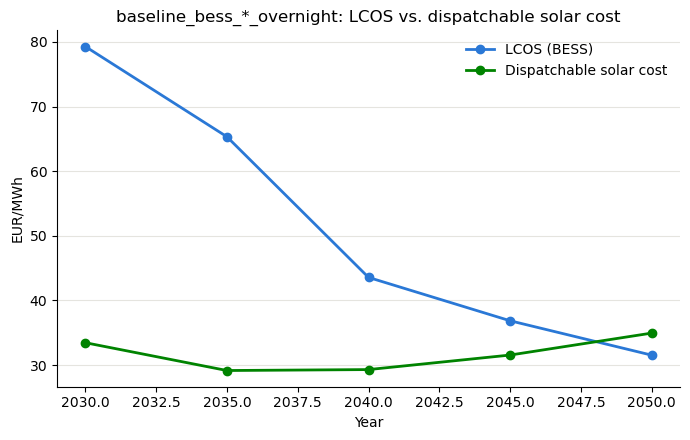

In [13]:
import matplotlib.pyplot as plt

bess_years = summary.index.str.extract(r"baseline_bess_(\d{4})_overnight")[0]
bess_trend = summary[bess_years.notna().values].copy()
bess_trend.index = bess_years.dropna().astype(int)
bess_trend = bess_trend.sort_index()

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(bess_trend.index, bess_trend["lcos_eur_mwh"], marker="o", markersize=6,
        linewidth=2, color="#2a78d6", label="LCOS (BESS)")
ax.plot(bess_trend.index, bess_trend["dispatchable_solar_cost_eur_mwh"], marker="o", markersize=6,
        linewidth=2, color="#008300", label="Dispatchable solar cost")
ax.set_xlabel("Year")
ax.set_ylabel("EUR/MWh")
ax.set_title("baseline_bess_*_overnight: LCOS vs. dispatchable solar cost")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#e5e4df", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()